In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline              # Дает возможность объединить все этапы, которые проходят X и y до обучения модели
from sklearn.model_selection import GridSearchCV   # Автоматический подбор гиперпараметров на основе заданного критерия
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

In [2]:
def visualize_prediction(y_true, y_pred, model):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()
    plt.show()

def show_metrics(y_true, y_pred):
    print('Среднее значение Y: ', np.mean(y_true))
    print('Accuracy: ', accuracy_score(y_true, y_pred)),
    print('Precision: ', precision_score(y_true, y_pred))
    print('Recall: ', recall_score(y_true, y_pred))
    print('F1: ', f1_score(y_true, y_pred))
    print('ROC-AUC: ', roc_auc_score(y_true, y_pred))

# 1. Загружаем датасет

In [3]:
data = sm.datasets.get_rdataset("mlc_churn", 'modeldata').data
data['target'] = np.where(data["churn"] == 'yes', 1, 0)
data["total_charge"] = data[[col for col in data.columns if col.find("charge")!= -1]].sum(axis = 1)

data.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,...,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn,target,total_charge
0,KS,128,area_code_415,no,yes,25,265.1,110,45.07,197.4,...,244.7,91,11.01,10.0,3,2.70,1,no,0,75.56
1,OH,107,area_code_415,no,yes,26,161.6,123,27.47,195.5,...,254.4,103,11.45,13.7,3,3.70,1,no,0,59.24
2,NJ,137,area_code_415,no,no,0,243.4,114,41.38,121.2,...,162.6,104,7.32,12.2,5,3.29,0,no,0,62.29
3,OH,84,area_code_408,yes,no,0,299.4,71,50.90,61.9,...,196.9,89,8.86,6.6,7,1.78,2,no,0,66.80
4,OK,75,area_code_415,yes,no,0,166.7,113,28.34,148.3,...,186.9,121,8.41,10.1,3,2.73,3,no,0,52.09


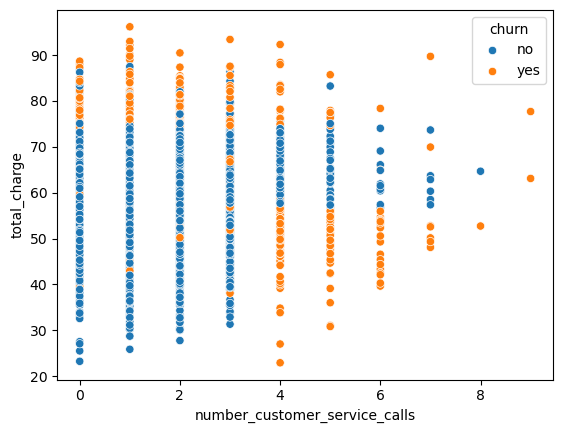

In [4]:
fig = plt.figure()
sns.scatterplot(data = data, x = 'number_customer_service_calls', y = 'total_charge', hue = 'churn')
plt.show()

In [7]:
target_col = ["target"]
features_col = ["number_customer_service_calls","total_charge"]

X = data[features_col]
y = data[target_col]

# Вся выборка делится на 60% обучающей и 40% тестовой
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42, stratify = y)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Бустинг

## 2.1. Бустинг вручную

In [8]:
# Инициализуем базовый "наивный" классификатор - дерево с глубиной = 1
base_model = DecisionTreeClassifier(max_depth = 1, random_state = 42)

In [27]:
# Инициализуем веса наблюдений
train_size = X_train_scaled.shape[0]
sample_weights = np.ones(train_size) / train_size

In [28]:
sample_weights

array([0.00029851, 0.00029851, 0.00029851, ..., 0.00029851, 0.00029851,
       0.00029851], shape=(3350,))

### Итерация 1

**Шаг 1:** Обучаем базовую модель и делаем предсказания для обучающей выборки

In [11]:
base_model.fit(X_train_scaled, y_train, sample_weight = sample_weights)
y_train_base_pred = base_model.predict(X_train_scaled)
y_train_base_pred

array([0, 0, 0, ..., 0, 0, 1], shape=(3350,))

**Шаг 2:** Считаем суммарную взвешенную ошибку

$$ 𝑒_𝑡= \sum_{i=1}^N(𝑤[𝑖]\cdot 1_{𝑦[𝑖] \neq 𝑎_𝑡 (𝑥[𝑖])})$$

In [20]:
err = np.sum(sample_weights * (y_train_base_pred != y_train.values.ravel()))
err

np.float64(0.09940298507462686)

**Шаг 3:** Считаем вес алгоритма

$$\alpha_𝑡 = \frac{1}{2} \ln {\frac{1−𝑒_𝑡}{𝑒_𝑡}}$$

In [21]:
alpha = 0.5 * np.log((1 - err) / (err + 1e-10))
alpha

np.float64(1.1019378740863057)

**Шаг 4:** Пересчитываем веса наблюдений

$$ 𝑤[𝑖] = 𝑤[𝑖] \cdot 𝑒^{−\alpha_𝑡 \cdot 𝑦[𝑖] \cdot 𝑎_𝑡(𝑥[𝑖])}$$

In [22]:
y_train.assign(y_pred = y_train_base_pred).head(10)

,target,y_pred
4151,0,0
3978,1,0
3121,0,0
3117,0,0
437,1,1
545,0,0
3808,0,0
674,0,0
3066,0,0
4770,0,0


В наблюдении номер 3978 допущена ошибка

In [29]:
sample_weights = sample_weights * np.exp(-alpha * np.where(y_train.values.ravel() == 1, 1, -1) * np.where(y_train_base_pred == 1, 1, -1))
sample_weights[0:10]

array([9.91721332e-05, 8.98505482e-04, 9.91721332e-05, 9.91721332e-05,
       9.91721332e-05, 9.91721332e-05, 9.91721332e-05, 9.91721332e-05,
       9.91721332e-05, 9.91721332e-05])

In [30]:
sample_weights.shape

(3350,)

Видим, что наблюдение под номером 2 имеет более высокий вес

**Шаг 5:** Нормируем веса

In [31]:
sample_weights = sample_weights/np.sum(sample_weights)
np.sum(sample_weights)

np.float64(1.0)

In [32]:
sample_weights[0:10]

array([0.00016573, 0.0015015 , 0.00016573, 0.00016573, 0.00016573,
       0.00016573, 0.00016573, 0.00016573, 0.00016573, 0.00016573])

### Итерация 2

**Шаг 1**

In [33]:
base_model = DecisionTreeClassifier(max_depth = 1)
base_model.fit(X_train_scaled, y_train, sample_weight = sample_weights)
y_train_base_pred = base_model.predict(X_train_scaled)
y_train_base_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(3350,))

**Шаг 2**

In [35]:
err = np.sum(sample_weights * (y_train_base_pred != y_train.values.ravel()))
err

np.float64(0.29977624283475857)

**Шаг 3**

In [36]:
alpha = 0.5 * np.log((1 - err) / (err + 1e-10))
alpha

np.float64(0.4241817987880044)

**Шаг 4**

In [38]:
sample_weights = sample_weights * np.exp(-alpha * np.where(y_train.values.ravel() == 1, 1, -1) * np.where(y_train_base_pred == 1, 1, -1))
np.sum(sample_weights)

np.float64(0.916319697630984)

In [39]:
sample_weights.shape

(3350,)

**Шаг 5**

In [40]:
sample_weights = sample_weights/np.sum(sample_weights)
sample_weights.sum()

np.float64(1.0)

In [41]:
sample_weights[0: 10]

array([0.00011834, 0.00250437, 0.00011834, 0.00011834, 0.00027642,
       0.00011834, 0.00011834, 0.00011834, 0.00011834, 0.00011834])

### Следующая итерация

In [42]:
base_model = DecisionTreeClassifier(max_depth = 1)
base_model.fit(X_train_scaled, y_train, sample_weight = sample_weights)
y_train_base_pred = base_model.predict(X_train_scaled)
y_train_base_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(3350,))

In [44]:
err = np.sum(sample_weights * (y_train_base_pred != y_train.values.ravel()))
err

np.float64(0.42583830090091923)

In [45]:
alpha = 0.5 * np.log((1 - err) / (err + 1e-10))
alpha

np.float64(0.14942568164909564)

In [46]:
sample_weights = sample_weights * np.exp(-alpha * np.where(y_train.values.ravel() == 1, 1, -1) * np.where(y_train_base_pred == 1, 1, -1))
np.sum(sample_weights)

np.float64(0.9889389109277424)

In [47]:
sample_weights = sample_weights/np.sum(sample_weights)
sample_weights.sum()

np.float64(1.0)

### Запускаем цикл на 100 повторений

In [48]:
n_samples = 100
train_size = X_train_scaled.shape[0]
sample_weights = np.ones(train_size) / train_size
models = []
alphas = []
errors = []

for _ in range(n_samples):
  base_model = DecisionTreeClassifier(max_depth = 2, random_state = 42)
  base_model.fit(X_train_scaled, y_train, sample_weight = sample_weights)
  predictions = base_model.predict(X_train_scaled)

  err = np.sum(sample_weights * (predictions != y_train.values.ravel()))

  alpha = 0.5 * np.log((1 - err) / (err + 1e-10))

  models.append(base_model)
  alphas.append(alpha)
  errors.append(err)
  sample_weights = sample_weights*np.exp(-alpha * np.where(y_train.values.ravel() == 1, 1, -1) * np.where(predictions == 1, 1, -1))
  sample_weights = sample_weights / np.sum(sample_weights)

In [50]:
strong_preds = np.zeros(y_test.shape[0])

for model, alpha in zip(models, alphas):
  predictions = model.predict(X_test_scaled)
  strong_preds += alpha * np.where(predictions == 1, 1, -1)

y_test_pred = np.where(np.sign(strong_preds).astype(int) == -1, 0, 1)

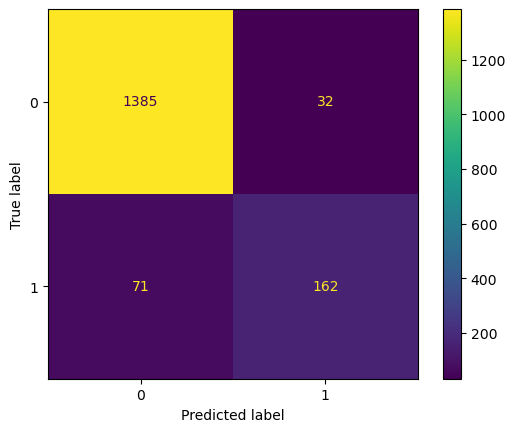

Среднее значение Y:  0.1412121212121212
Accuracy:  0.9375757575757576
Precision:  0.8350515463917526
Recall:  0.6952789699570815
F1:  0.7587822014051522
ROC-AUC:  0.8363480241457955


In [52]:
visualize_prediction(y_test, y_test_pred, base_model)
show_metrics(y_test, y_test_pred)

## 2.2. Бустинг автоматически

In [53]:
clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth = 2), n_estimators = 100)
clf.fit(X_train_scaled, y_train)

C:\Users\D\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                   n_estimators=100)

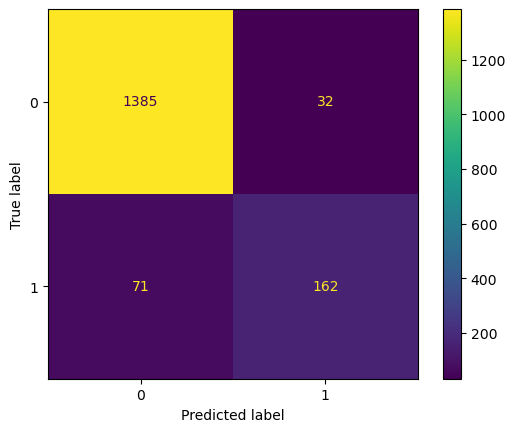

Среднее значение Y:  0.1412121212121212
Accuracy:  0.9375757575757576
Precision:  0.8350515463917526
Recall:  0.6952789699570815
F1:  0.7587822014051522
ROC-AUC:  0.8363480241457955


In [54]:
y_test_pred = clf.predict(X_test_scaled)
visualize_prediction(y_test, y_test_pred, clf)
show_metrics(y_test, y_test_pred)

## 2.3. Проведем тюнинг гиперпараметров

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [56]:
pipe = Pipeline(steps=[("scaler", StandardScaler()), ("classify", AdaBoostClassifier(DecisionTreeClassifier(max_depth = 2), random_state = 42))])
param_grid = {"classify__n_estimators": [10, 50, 100, 150]}
search = GridSearchCV(pipe, param_grid, scoring = 'f1')
search.fit(X_train, y_train.values.ravel())
best_model = search.best_estimator_
y_test_pred = best_model.predict(X_test)

In [58]:
best_model.get_params()['classify__n_estimators']

10

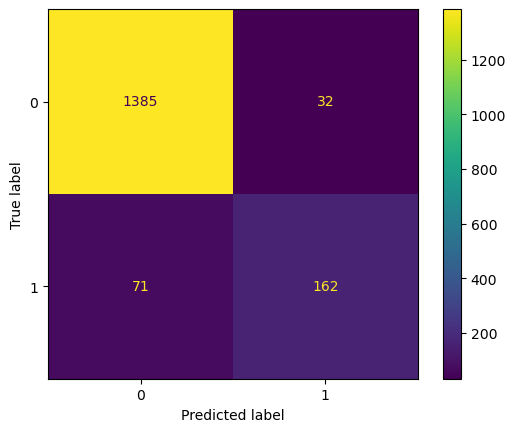

Среднее значение Y:  0.1412121212121212
Accuracy:  0.9375757575757576
Precision:  0.8350515463917526
Recall:  0.6952789699570815
F1:  0.7587822014051522
ROC-AUC:  0.8363480241457955


In [61]:
visualize_prediction(y_test, y_test_pred, best_model)
show_metrics(y_test, y_test_pred)

# 3. Градиентный бустинг

## 3.1. GradientBoostingClassifier

In [63]:
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
gbc = GradientBoostingClassifier(random_state = 42)
gbc.fit(X_train_scaled, y_train.values.ravel())
y_test_pred = gbc.predict(X_test_scaled)

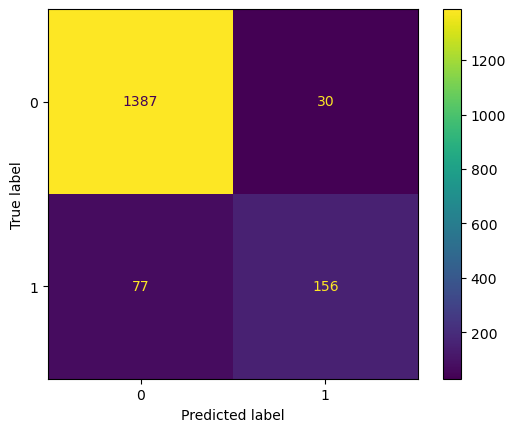

Среднее значение Y:  0.1412121212121212
Accuracy:  0.9351515151515152
Precision:  0.8387096774193549
Recall:  0.6695278969957081
F1:  0.7446300715990454
ROC-AUC:  0.8241782039671555


In [64]:
visualize_prediction(y_test, y_test_pred, gbc)
show_metrics(y_test, y_test_pred)

In [65]:
pipe = Pipeline(steps=[("scaler", StandardScaler()), ("classify", GradientBoostingClassifier(random_state = 42))])
param_grid = {
    "classify__n_estimators": [10, 50, 100, 150],
    "classify__max_depth": np.linspace(start = 1, stop = 10, num = 10, dtype = int),
    "classify__learning_rate": np.linspace(start = 0, stop = 1, num = 11)
    }
search = GridSearchCV(pipe, param_grid, scoring = 'f1')
search.fit(X_train_scaled, y_train.values.ravel())
best_model = search.best_estimator_
y_test_pred = best_model.predict(X_test_scaled)


KeyboardInterrupt



In [ ]:
visualize_prediction(y_test, y_test_pred, gbc)
show_metrics(y_test, y_test_pred)

## 3.2. HistGradientBoostingClassifier

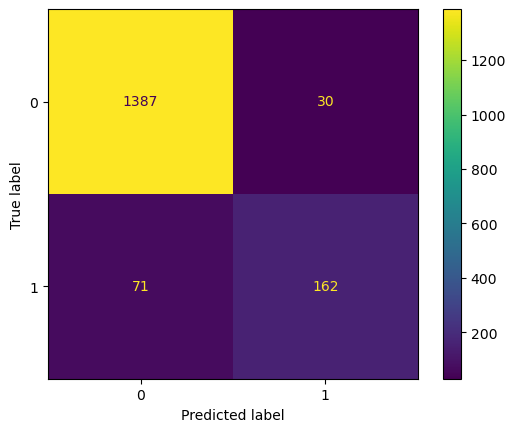

Среднее значение Y:  0.1412121212121212
Accuracy:  0.9387878787878788
Precision:  0.84375
Recall:  0.6952789699570815
F1:  0.7623529411764706
ROC-AUC:  0.8370537404478421


In [67]:
hgbc = HistGradientBoostingClassifier(random_state = 42)
hgbc.fit(X_train_scaled, y_train.values.ravel())
y_test_pred = hgbc.predict(X_test_scaled)

visualize_prediction(y_test, y_test_pred, hgbc)
show_metrics(y_test, y_test_pred)

## 3.3. XGBoost Classifier

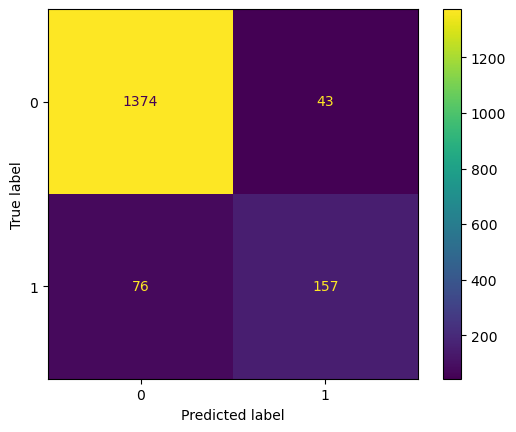

Среднее значение Y:  0.1412121212121212
Accuracy:  0.9278787878787879
Precision:  0.785
Recall:  0.6738197424892703
F1:  0.7251732101616628
ROC-AUC:  0.8217369707506338


In [70]:
from xgboost import XGBClassifier

xgbc = XGBClassifier(seed = 42)
xgbc.fit(X_train_scaled, y_train.values.ravel())
y_test_pred = xgbc.predict(X_test_scaled)

visualize_prediction(y_test, y_test_pred, xgbc)
show_metrics(y_test, y_test_pred)

## 3.4. Light GBM

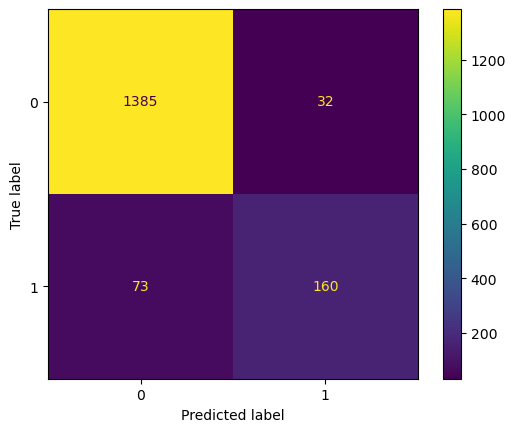

Среднее значение Y:  0.1412121212121212
Accuracy:  0.9363636363636364
Precision:  0.8333333333333334
Recall:  0.6866952789699571
F1:  0.7529411764705882
ROC-AUC:  0.8320561786522334


In [74]:
from lightgbm import LGBMClassifier

lgb_clf = LGBMClassifier(random_state = 42, verbose=-1)
lgb_clf.fit(X_train_scaled, y_train.values.ravel())
y_test_pred = lgb_clf.predict(X_test_scaled)

visualize_prediction(y_test, y_test_pred, lgb_clf)
show_metrics(y_test, y_test_pred)

## 3.5. CatBoost

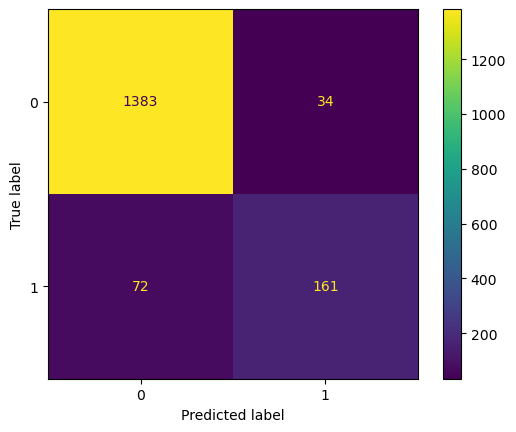

Среднее значение Y:  0.1412121212121212
Accuracy:  0.9357575757575758
Precision:  0.8256410256410256
Recall:  0.6909871244635193
F1:  0.7523364485981309
ROC-AUC:  0.8334963850969679


In [75]:
from catboost import CatBoostClassifier

cb_clf = CatBoostClassifier(random_seed = 42, logging_level='Silent')
cb_clf.fit(X_train_scaled, y_train.values.ravel())
y_test_pred = cb_clf.predict(X_test_scaled).squeeze()

visualize_prediction(y_test, y_test_pred, cb_clf)
show_metrics(y_test, y_test_pred)

In [80]:
# Значимость признаков
pd.DataFrame(
    cb_clf.feature_importances_,
    index = X_train.columns, 
    columns = ['feature_importance']
).sort_values(by = 'feature_importance', ascending = False)

,feature_importance
total_charge,59.322553
number_customer_service_calls,40.677447
